# Extension 1 — Dynamic misspecification: a VARMA(4,1) DGP (Chapter 4)

This notebook stress-tests the Chapter 3 baseline ranking under **dynamic misspecification**. The DGP
augments the baseline VAR(4) with a first-order moving-average term,
$$ y_t = \sum_{i=1}^4 A_i y_{t-i} + u_t + \Theta u_{t-1}, \qquad \Theta = \tau I_2, \quad u_t = B\varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, I_2), $$
with misspecification strength $\tau \in \{0.1, 0.3, 0.6\}$, where $\tau = 0$ nests the baseline VAR(4).
The lag matrices $A_i$ and the impact matrix $B$ are inherited from the baseline, so **all** variation
across scenarios comes from the MA component.

The VARMA is invertible, so it admits a VAR($\infty$) representation. A high-order VAR($q$) can therefore
approximate it, the equal-lag **VAR(4)** cannot (it carries an asymptotic bias that does not vanish with
$T$), and **LP(4)** is robust by construction (Montiel Olea et al.). Both estimators, the fixed **LP(4)**
and the **VAR($q$) sweep** ($q = 1, \dots, p + H - 1$), are applied **unchanged**. The estimand is the
true VARMA structural IRF $\theta_h = (\Phi_h B)[1, 1]$, computed analytically for each $\tau$.

In [2]:
# Standard scientific Python stack plus the project package `mcsim`
# (installed in editable mode via `pip install -e .`).
from functools import partial

import numpy as np
import matplotlib.pyplot as plt

# Project modules: VAR/VARMA DGPs and their true IRFs, the estimators, and the MC driver.
from mcsim.dgp import (VARSpec, VARMASpec, simulate_varma, varma_irf,
                       scale_to_persistence, spectral_radius)
from mcsim.estimators import estimate_lp_irf, estimate_var_irf, fit_var_ols
from mcsim.simulation import MCConfig, run

## 0. Model parameters

The parameters below extend the Chapter 3 baseline with the MA component. Everything except the
misspecification grid is inherited unchanged. The persistence **scenario** is selected in the next cell.

In [3]:
# One of "LOW" (rho = 0.5), "MID" (rho = 0.7), or "HIGH" (rho = 0.95).
Scenario = "HIGH"

SEED = 42                                     # master RNG seed, shared by every stochastic step
P = 4                                         # AR lag order of the baseline
H = 20                                        # maximum IRF horizon
N_REPS = 5000                                 # Monte Carlo replications per configuration

# Map the scenario label to its target persistence (spectral radius of the AR companion matrix).
RHO_SCENARIO = {"LOW": 0.5, "MID": 0.7, "HIGH": 0.95}
RHO = RHO_SCENARIO[Scenario]

T = [100, 250, 500]                           # sample sizes
TAUS = [0.0, 0.1, 0.3, 0.6]                   # MA misspecification strength (tau=0 nests baseline VAR(4))
T_SHOW = 250                                  # sample size used for the per-tau diagnostic panels

# Baseline VAR(4) coefficients, shared across tau. Geometrically decaying, symmetric lag matrices.
M  = np.array([[0.50, 0.10], [0.10, 0.50]])   # symmetric, positive -> real, decaying response
A0 = np.array([M, 0.4 * M, 0.2 * M, 0.1 * M]) # unscaled lag matrices A1..A4
B  = np.array([[1.0, 0.0], [0.5, 1.0]])       # recursive (lower-triangular) impact matrix
A_RHO = scale_to_persistence(A0, RHO)         # AR part scaled to target persistence; shared across tau

# VARMA(4,1) with Theta_1 = tau * I_2; tau=0 reproduces the baseline VAR(4) exactly.
DGPS = {tt: VARMASpec(A=A_RHO, Theta=np.array([tt * np.eye(2)]), B=B) for tt in TAUS}
print("AR spectral radius (persistence):", round(spectral_radius(A_RHO), 3),
      "| MA(1) root modulus 1/tau > 1 for tau<1 -> invertible (VAR-infinity exists)")

AR spectral radius (persistence): 0.95 | MA(1) root modulus 1/tau > 1 for tau<1 -> invertible (VAR-infinity exists)


## 1. The data-generating process and its true impulse response

The figure shows the true structural estimand $\theta_h = (\Phi_h B)[1, 1]$ for each $\tau$, computed
analytically with no estimation. The MA term $\Theta u_{t-1}$ injects extra **short-horizon**
propagation that lifts the early-horizon IRF, so as $\tau$ grows the response peaks higher near $h = 1$
before decaying. The case $\tau = 0$ recovers the baseline VAR(4).

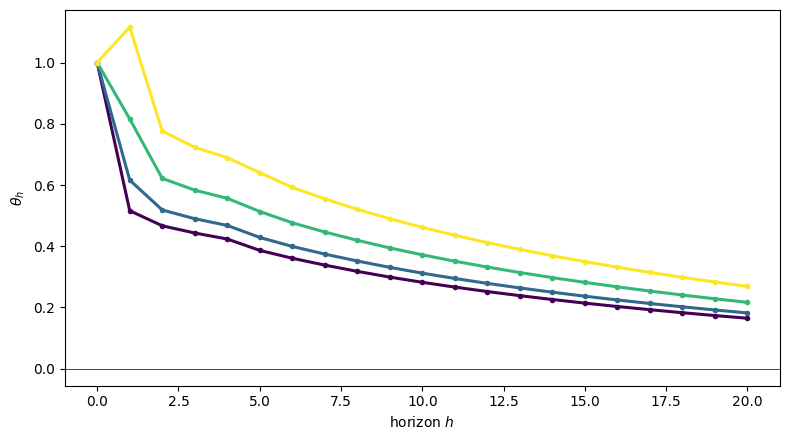

In [4]:
# True structural IRFs (no estimation) for each misspecification strength.
# Under VARMA(4,1) the MA term injects extra short-horizon propagation that lifts the
# early-horizon estimand; tau=0 nests the baseline VAR(4).
hgrid = np.arange(H + 1)
truth_byTau = {tt: varma_irf(DGPS[tt], H) for tt in TAUS}
ctau = {tt: plt.cm.viridis(i / max(len(TAUS) - 1, 1)) for i, tt in enumerate(TAUS)}

fig, ax = plt.subplots(figsize=(8, 4.5))
for tt in TAUS:
    lab = "τ=0  (baseline VAR(4))" if tt == 0 else f"τ={tt}"
    ax.plot(hgrid, truth_byTau[tt], "o-", lw=2.2, ms=3, color=ctau[tt], label=lab)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("horizon $h$")
ax.set_ylabel(r"$\theta_h$")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_IRF_rho={RHO}.png")
plt.show()

## 2. Monte Carlo: LP(4) and the VAR(q) sweep across misspecification and sample size

This implements the three-way design of Chapter 4. For each $\tau \in \{0, 0.1, 0.3, 0.6\}$ and
$T \in \{100, 250, 500\}$ we run the fixed **LP(4)** and the full **VAR(q) sweep** ($q = 1, \dots, 23$)
on VARMA-generated data, **without modification**. The estimand is $T$-independent but
**$\tau$-dependent** (`truth_byTau`). The raw IRF draws land in `results[(τ, T)]` and the horizon-wise
RMSE in `rmse[(τ, T)]`.

In [5]:
# Estimators under comparison, each a one-argument callable `estimator(data) -> IRF`.
VAR_ORDERS = list(range(1, P + H))            # 1, 2, ..., 23

estimators = {"LP(4)": partial(estimate_lp_irf, p=P, horizon=H)}
estimators.update({f"VAR({q})": partial(estimate_var_irf, p=q, horizon=H) for q in VAR_ORDERS})


def varma_dgp(rng, Tlen, spec):
    """DGP callable for the driver: simulate one VARMA path of length Tlen."""
    return simulate_varma(spec, Tlen, rng)


# Run the Monte Carlo for every (tau, T) cell; the estimand depends on tau.
results, rmse = {}, {}                         # keyed by (tau, T)
for tt in TAUS:
    truth = truth_byTau[tt]
    for Tval in T:
        cfg = MCConfig(n_reps=N_REPS, T=Tval, horizon=H, seed=SEED, n_jobs=-1,
                       progress=True, estimators=estimators)
        res = run(partial(varma_dgp, spec=DGPS[tt]), cfg)
        results[(tt, Tval)] = res
        rmse[(tt, Tval)] = {nm: np.sqrt(np.nanmean((st - truth) ** 2, axis=0))
                            for nm, st in res["irfs"].items()}
        fails = {k: v for k, v in res["n_failures"].items() if v}
        print(f"tau={tt:<4} T={Tval:>4}: done  |  failures: {fails or 'none'}")

MC reps: 100%|██████████| 5000/5000 [00:08<00:00, 586.88it/s]


tau=0.0  T= 100: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:10<00:00, 490.24it/s]


tau=0.0  T= 250: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:13<00:00, 380.75it/s]


...

tau=0.6  T= 100: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:11<00:00, 424.17it/s]


tau=0.6  T= 250: done  |  failures: none


MC reps: 100%|██████████| 5000/5000 [00:14<00:00, 348.03it/s]


tau=0.6  T= 500: done  |  failures: none


## 3. RMSE comparison: does the ranking survive misspecification?

The **complexity frontier** (horizon-averaged RMSE against VAR order) at $T = 250$, one curve per
$\tau$, with LP(4) as a same-colour dashed reference. As $\tau$ grows, the equal-lag VAR(4) end of the
frontier should lift, since four lags cannot fit the MA dynamics, while higher-order VARs and LP(4)
absorb it. The table below reports every $(\tau, T)$ cell.

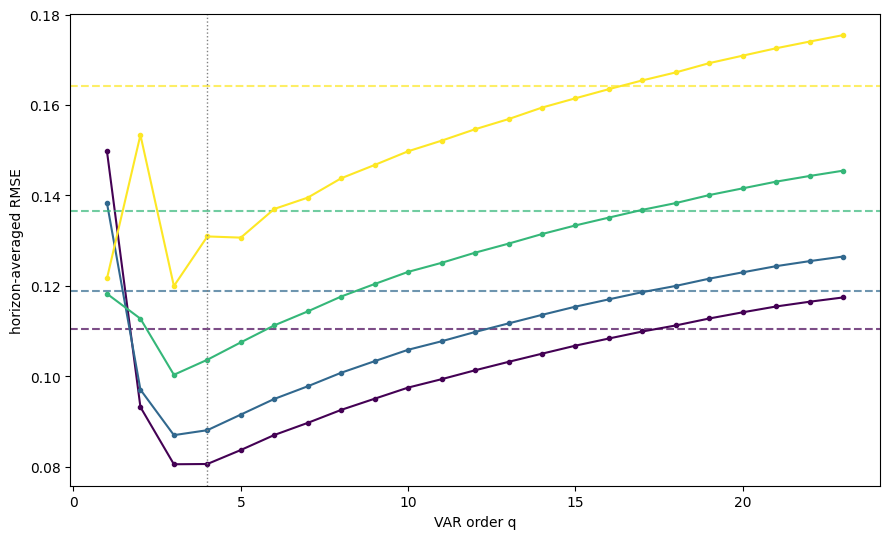

   tau     T    LP(4)   VAR(4)        bestVAR   LP-VAR4
--------------------------------------------------------
   0.0   100    0.197    0.137   VAR(3)=0.133    +0.060
   0.0   250    0.110    0.081   VAR(3)=0.081    +0.030
   0.0   500    0.074    0.054   VAR(4)=0.054    +0.020
   0.1   100    0.213    0.150   VAR(3)=0.145    +0.063
   0.1   250    0.119    0.088   VAR(3)=0.087    +0.031
   0.1   500    0.080    0.059   VAR(4)=0.059    +0.020
   0.3   100    0.246    0.177   VAR(3)=0.169    +0.068
   0.3   250    0.137    0.104   VAR(3)=0.100    +0.033
   0.3   500    0.091    0.070   VAR(3)=0.068    +0.022
   0.6   100    0.297    0.222   VAR(1)=0.195    +0.075
   0.6   250    0.164    0.131   VAR(3)=0.120    +0.033
   0.6   500    0.109    0.089   VAR(3)=0.082    +0.021
(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)


In [6]:
# (1) Complexity frontier per tau, at the diagnostic sample size T_SHOW.
#     Solid line = VAR(q); dashed horizontal line = LP(4) reference in the same colour.
fig, ax = plt.subplots(figsize=(9, 5.5))
for tt in TAUS:
    rm = rmse[(tt, T_SHOW)]
    avg_var = [np.mean(rm[f"VAR({q})"]) for q in VAR_ORDERS]
    lab = "τ=0 (baseline)" if tt == 0 else f"τ={tt}"
    ax.plot(VAR_ORDERS, avg_var, "o-", ms=3, color=ctau[tt], label=lab)
    ax.axhline(np.mean(rm["LP(4)"]), ls="--", color=ctau[tt], alpha=0.7)
ax.axvline(4, color="gray", ls=":", lw=1)     # equal-lag VAR(4) reference
ax.set_xlabel("VAR order q")
ax.set_ylabel("horizon-averaged RMSE")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_COMPLEXITY_FRONTIER_rho={RHO}_T={T_SHOW}.png")
plt.show()

# (2) Full (tau, T) summary table of horizon-averaged RMSE.
#     LP-VAR4 > 0 means VAR(4) has the lower RMSE.
print(f"{'tau':>6} {'T':>5} {'LP(4)':>8} {'VAR(4)':>8} {'bestVAR':>14} {'LP-VAR4':>9}")
print("-" * 56)
for tt in TAUS:
    for Tval in T:
        rm = rmse[(tt, Tval)]
        lp = float(np.mean(rm["LP(4)"]))
        v4 = float(np.mean(rm["VAR(4)"]))
        avgs = {q: float(np.mean(rm[f"VAR({q})"])) for q in VAR_ORDERS}
        bq = min(avgs, key=avgs.get)
        print(f"{tt:>6} {Tval:>5} {lp:8.3f} {v4:8.3f} {f'VAR({bq})={avgs[bq]:.3f}':>14} {lp - v4:+9.3f}")
print("(horizon-averaged RMSE;  LP-VAR4 > 0 = VAR(4) better)")

## 4. Point-estimation metrics under misspecification

The same per-horizon **bias / variance / MSE / RMSE** decomposition as the baseline, now at the
strongest misspecification $\tau = 0.6$ and $T = 250$. Unlike the correctly specified baseline (where
the VAR bias is approximately zero), here the low-order VARs carry genuine bias, so
$\mathrm{MSE}_h = \mathrm{Bias}_h^2 + \mathrm{Var}_h$ has a non-negligible squared-bias component at
short horizons. The Monte Carlo standard error $\mathrm{MCSE}(\widehat{\mathrm{Bias}}_h) = \sqrt{\widehat{\mathrm{Var}}_h / B}$ bounds the simulation noise.

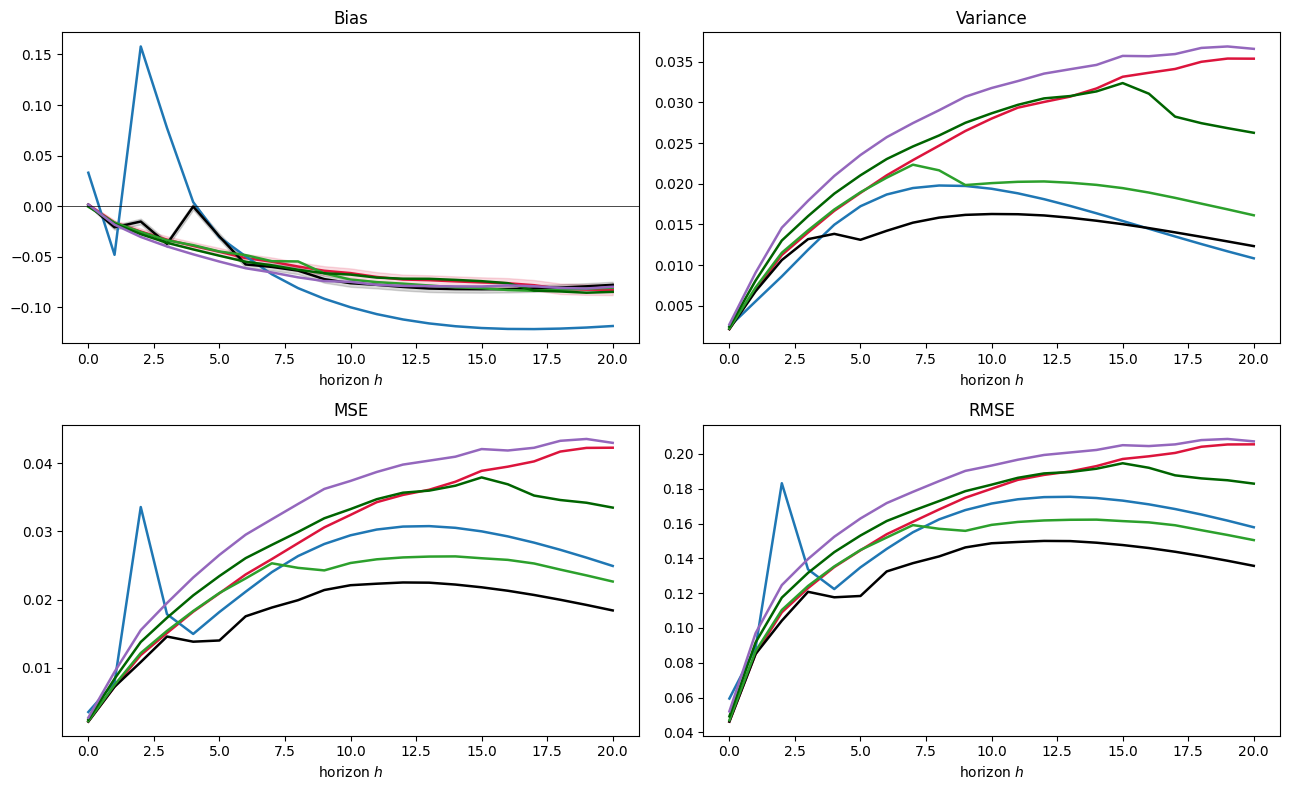

τ=0.6, T=250, B=5000   |   typical MCSE(bias) ~ 0.0015


h=1             h=8            h=20        
           bias    RMSE    bias    RMSE    bias    RMSE
LP(4)   -0.0164  0.0851 -0.0598  0.1681 -0.0829  0.2055
VAR(2)  -0.0483  0.0887 -0.0812  0.1624 -0.1187  0.1579
VAR(4)  -0.0211  0.0850 -0.0639  0.1411 -0.0780  0.1357
VAR(8)  -0.0164  0.0866 -0.0548  0.1570 -0.0808  0.1505
VAR(16) -0.0175  0.0917 -0.0631  0.1729 -0.0849  0.1829
VAR(23) -0.0184  0.0970 -0.0706  0.1844 -0.0799  0.2072

In [7]:
import pandas as pd
from IPython.display import display


def metrics(stack, truth):
    """Per-horizon Chapter 3 point metrics for a (B, H+1) stack of IRF estimates."""
    B = int(np.sum(~np.isnan(stack[:, 0])))
    mean = np.nanmean(stack, axis=0)
    bias = mean - truth
    var = np.nanvar(stack, axis=0, ddof=1)
    mse = np.nanmean((stack - truth) ** 2, axis=0)
    return dict(bias=bias, var=var, mse=mse, rmse=np.sqrt(mse),
                mcse_bias=np.sqrt(var / B), B=B)


TAU_SHOW, Tval = 0.6, T_SHOW                   # strongest misspecification cell
truth = truth_byTau[TAU_SHOW]
sel = ["LP(4)", "VAR(2)", "VAR(4)", "VAR(8)", "VAR(16)", "VAR(23)"]
colm = {"LP(4)": "crimson", "VAR(2)": "tab:blue", "VAR(4)": "black",
        "VAR(8)": "tab:green", "VAR(16)": "darkgreen", "VAR(23)": "tab:purple"}
m = {nm: metrics(results[(TAU_SHOW, Tval)]["irfs"][nm], truth) for nm in sel}

# Four-panel figure: bias, variance, MSE, RMSE by horizon.
fig, ax = plt.subplots(2, 2, figsize=(13, 8))
for nm in sel:
    ax[0, 0].plot(hgrid, m[nm]["bias"], color=colm[nm], lw=1.8, label=nm)
    ax[0, 1].plot(hgrid, m[nm]["var"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 0].plot(hgrid, m[nm]["mse"], color=colm[nm], lw=1.8, label=nm)
    ax[1, 1].plot(hgrid, m[nm]["rmse"], color=colm[nm], lw=1.8, label=nm)

# Monte Carlo standard-error band on the bias for two reference estimators.
for nm in ("LP(4)", "VAR(4)"):
    lo = m[nm]["bias"] - 1.96 * m[nm]["mcse_bias"]
    hi = m[nm]["bias"] + 1.96 * m[nm]["mcse_bias"]
    ax[0, 0].fill_between(hgrid, lo, hi, color=colm[nm], alpha=0.15)

ax[0, 0].axhline(0, color="k", lw=0.5)
ax[0, 0].set_title("Bias")
ax[0, 1].set_title("Variance")
ax[1, 0].set_title("MSE")
ax[1, 1].set_title("RMSE")
for a in ax.ravel():
    a.set_xlabel("horizon $h$")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_POINT_ESTIMATION_rho={RHO}_T={T_SHOW}_B=5000_tau={TAU_SHOW}.png")
plt.show()

# Compact table: bias and RMSE at selected horizons.
report = [1, 8, 20]
rows = {nm: {(f"h={h}", k): m[nm][{"bias": "bias", "RMSE": "rmse"}[k]][h]
             for h in report for k in ("bias", "RMSE")} for nm in sel}
tab = pd.DataFrame(rows).T
tab.columns = pd.MultiIndex.from_tuples(tab.columns)
print(f"τ={TAU_SHOW}, T={Tval}, B={N_REPS}   |   typical MCSE(bias) ~ "
      f"{np.mean([m['VAR(4)']['mcse_bias'][h] for h in report]):.4f}")
display(tab.round(4))

## 5. Inference: coverage under misspecification

Coverage of nominal 95% CIs for the **true** VARMA $\theta_h$, at the strongest misspecification
$\tau = 0.6$ (matching the point-estimation panel), in the **same format as the baseline**, comparing
the misspecified equal-lag **VAR(4)**, the high-order **VAR(23)**, and the robust **LP(4)**.

- **VAR(q): delta method**, which propagates the reduced-form coefficient uncertainty through
  $\theta_h = \hat\Psi_h \hat B e_1$ (variance only, with $B$ held fixed).
- **LP(4): HC1-robust SE** of the shock coefficient.

A variance-only CI ignores bias, so under misspecification it can only *miss* the truth more often as
the bias grows. The right panel validates the VAR(4) delta-method SE against the empirical sampling SD
of $\hat\theta_h$. Close agreement means the under-coverage is a *bias* effect rather than a broken SE.

coverage MC τ=0.6: 100%|██████████| 5000/5000 [00:44<00:00, 111.68it/s]


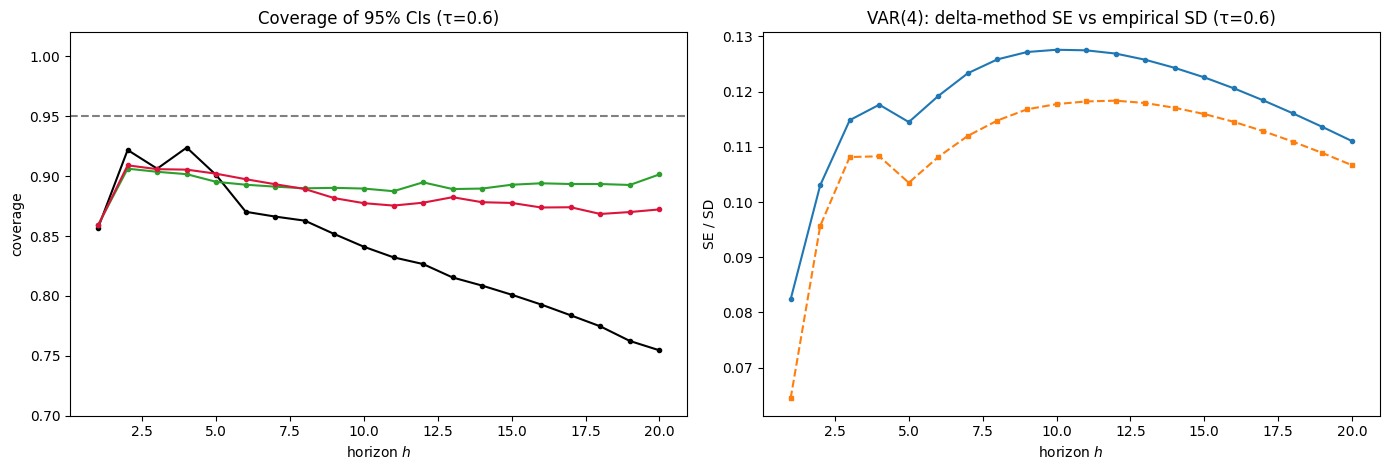

horizon-averaged coverage (h=1..20, τ=0.6):  VAR(4)=0.838   VAR(23)=0.892   LP(4)=0.883


In [8]:
from joblib import Parallel, delayed
from tqdm import tqdm

from mcsim.coverage import var_theta_se, lp_theta_se

T_COV = T_SHOW         # single sample-size cell for the coverage study
N_COV = 5000           # replications for the coverage Monte Carlo
Z = 1.96               # normal critical value for a nominal 95% two-sided CI
TAU_COV = 0.6          # fixed at the strongest misspecification (matches the point-estimation panel)
EST_COV = ["VAR(4)", "VAR(23)", "LP(4)"]   # same estimator set as the baseline coverage figure


def _coverage_rep(seed, spec):
    """One replication: simulate from the VARMA spec, return {estimator: (theta_hat, se)}."""
    rng = np.random.default_rng(seed)
    y = simulate_varma(spec, T_COV, rng)
    with np.errstate(divide="ignore", over="ignore", invalid="ignore"):
        return {
            "VAR(4)": var_theta_se(y, 4, H),
            "VAR(23)": var_theta_se(y, 23, H),
            "LP(4)": lp_theta_se(y, 4, H),
        }


truth = truth_byTau[TAU_COV]                   # estimand at the fixed misspecification
# Independent, reproducible RNG stream per replication (parallel-safe), as in mcsim.run.
seeds = np.random.SeedSequence(SEED).spawn(N_COV)
reps = Parallel(n_jobs=-1)(delayed(_coverage_rep)(s, DGPS[TAU_COV])
                           for s in tqdm(seeds, desc=f"coverage MC τ={TAU_COV}"))
theta_s = {nm: np.array([r[nm][0] for r in reps]) for nm in EST_COV}
se_s = {nm: np.array([r[nm][1] for r in reps]) for nm in EST_COV}

# Coverage_h = fraction of CIs [theta_hat +/- Z*se] that contain the TRUE theta_h.
coverage = {nm: np.nanmean((theta_s[nm] - Z * se_s[nm] <= truth) &
                           (truth <= theta_s[nm] + Z * se_s[nm]), axis=0) for nm in EST_COV}

# Validation: the VAR(4) delta-method SE should match the empirical sampling SD of theta_hat.
val_emp = np.nanstd(theta_s["VAR(4)"], axis=0, ddof=1)
val_se = np.nanmean(se_s["VAR(4)"], axis=0)

# Left panel: coverage by horizon. Right panel: delta-method SE vs empirical SD for VAR(4).
fig, (axc, axv) = plt.subplots(1, 2, figsize=(14, 4.8))
cc = {"VAR(4)": "black", "VAR(23)": "tab:green", "LP(4)": "crimson"}
_ylo = float(max(0.0, np.floor((min(np.nanmin(coverage[nm][1:]) for nm in EST_COV) - 0.02) * 20) / 20))
for nm in EST_COV:
    axc.plot(hgrid[1:], coverage[nm][1:], "o-", ms=3, color=cc[nm], label=nm)
axc.axhline(0.95, color="gray", ls="--", label="nominal 0.95")
axc.set_ylim(_ylo, 1.02)
axc.set_xlabel("horizon $h$")
axc.set_ylabel("coverage")
axc.set_title(f"Coverage of 95% CIs (τ={TAU_COV})")

axv.plot(hgrid[1:], val_emp[1:], "o-", ms=3, label="empirical SD of $\\hat\\theta_h$")
axv.plot(hgrid[1:], val_se[1:], "s--", ms=3, label="mean delta-method SE")
axv.set_xlabel("horizon $h$")
axv.set_ylabel("SE / SD")
axv.set_title(f"VAR(4): delta-method SE vs empirical SD (τ={TAU_COV})")
fig.tight_layout()
plt.savefig(f"../../figures/Dynamic_MisSpec/DYN_MISSPEC_COVERAGE_rho={RHO}_T{T_SHOW}_B=5000.png")
plt.show()

print(f"horizon-averaged coverage (h=1..{H}, τ={TAU_COV}):  " +
      "   ".join(f"{nm}={np.nanmean(coverage[nm][1:]):.3f}" for nm in EST_COV))